# 04 — Visualizations (Person 4)

**Project question:** what drives customer satisfaction (`average_rating`) on Amazon products?

This notebook covers Submission 1 task **4d — relevant visualizations**. All plotting code lives in `src/viz.py`; this notebook calls those functions and explains what each chart shows.

**Input:** the cleaned product table from Person 2 (`src/clean.py`), one row per product, 4 source categories.

**Output:** every chart is saved as a PNG in `reports/figures/` at 150 dpi, ready for the slide deck.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

from src import viz

## Load the cleaned data

`viz.load_clean_data()` reads Person 2's processed file if it exists. Otherwise it reads the raw file in chunks of 200,000 rows and passes each chunk through Person 2's `clean_products`. Only the columns the charts need are kept, so this stays light on memory.

In [2]:
df = viz.load_clean_data()
print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])
df.head()

Rows: 1,644,621 | Columns: 9


,category,main_category,store,average_rating,rating_number,price_num,has_price,n_features,n_description
0,All_Beauty,All Beauty,Howard Products,4.8,10,NaN,False,0,0
1,All_Beauty,All Beauty,Yes To,4.5,3,NaN,False,0,0
2,All_Beauty,All Beauty,Levine Health Products,4.4,26,NaN,False,0,0
3,All_Beauty,All Beauty,Cherioll,3.1,102,NaN,False,0,0
4,All_Beauty,All Beauty,Precision,4.3,7,NaN,False,5,1


## Chart conventions

- Each category keeps **the same colour in every chart** (set once in `viz.CATEGORY_COLORS`).
- Every chart has a title and axis labels with units.
- Price and number of ratings are drawn on a **log scale** because both are heavily skewed.
- Scatter charts draw a **random sample of 5,000 products per category** (fixed seed, so the picture never changes). Their trend lines use **all** products, not the sample.

## 1. Distribution of average rating

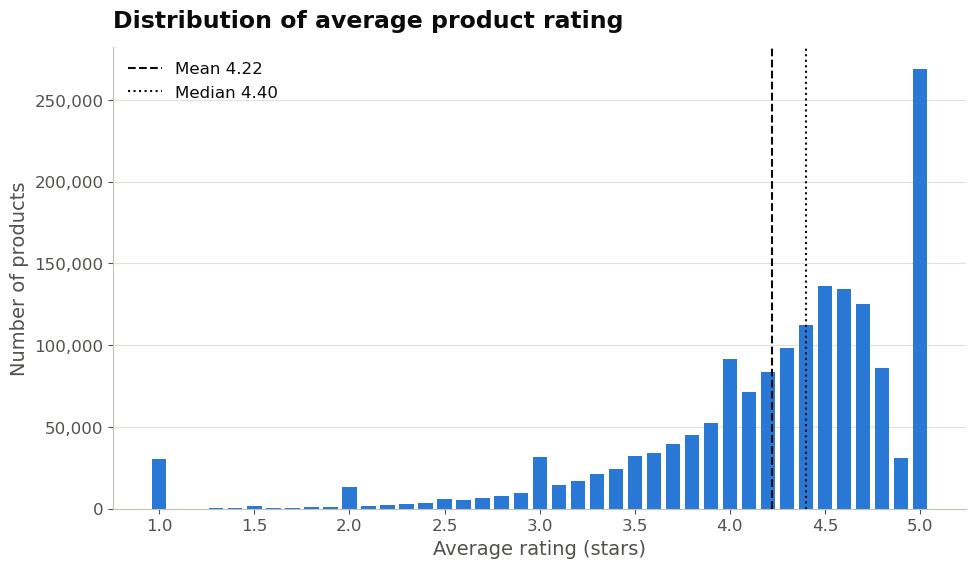

In [3]:
fig = viz.plot_rating_distribution(df)

In [4]:
# Numbers behind the commentary below
print("Share of products rated 4.0 or higher:", f"{100 * (df['average_rating'] >= 4.0).mean():.1f}%")
print("Share of products rated below 3.0:", f"{100 * (df['average_rating'] < 3.0).mean():.1f}%")
print()
print("Products at whole-number ratings, and how many of them have fewer than 10 ratings:")
for value in [5.0, 3.0, 2.0, 1.0]:
    at_value = df[df["average_rating"] == value]
    few = 100 * (at_value["rating_number"] < 10).mean()
    print(f"  rated {value}: {len(at_value):>7,} products ({100 * len(at_value) / len(df):.1f}% of all), {few:.1f}% with fewer than 10 ratings")
print("All products with fewer than 10 ratings:", f"{100 * (df['rating_number'] < 10).mean():.1f}%")

Share of products rated 4.0 or higher: 75.3%
Share of products rated below 3.0: 5.7%

Products at whole-number ratings, and how many of them have fewer than 10 ratings:
  rated 5.0: 269,110 products (16.4% of all), 94.8% with fewer than 10 ratings
  rated 3.0:  31,720 products (1.9% of all), 85.6% with fewer than 10 ratings
  rated 2.0:  13,117 products (0.8% of all), 98.9% with fewer than 10 ratings
  rated 1.0:  30,579 products (1.9% of all), 99.9% with fewer than 10 ratings
All products with fewer than 10 ratings: 43.0%


**What it shows.** Ratings are bunched at the top of the scale: the mean is 4.22 and the median 4.40, and 75.3% of products are rated 4.0 or higher. Only 5.7% sit below 3.0.

The tallest bar is exactly 5.0 (16.4% of products), but 94.8% of those products have fewer than 10 ratings, against 43.0% of all products. That spike is mostly products with very few ratings rather than proven favourites. The smaller spikes at 1.0, 2.0 and 3.0 are the same kind of product: 99.9%, 98.9% and 85.6% of them have fewer than 10 ratings.

## 2. Average rating by category

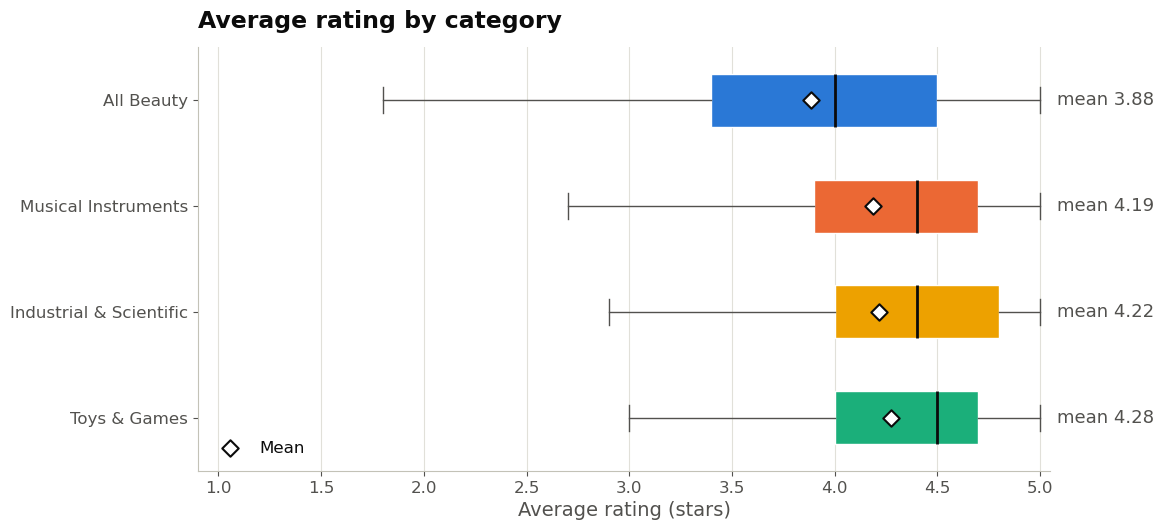

In [5]:
fig = viz.plot_rating_by_category(df)

**What it shows.** All Beauty is the clear low-rated category: its mean is 3.88 and its median 4.0, against means of 4.19 to 4.28 and medians of 4.4 to 4.5 for the other three. Its box is also the widest, so Beauty ratings are more spread out. The other three categories look very similar to each other.

Outlier points are hidden: with hundreds of thousands of products per category they would cover the whole axis.

## 3. Number of products per category

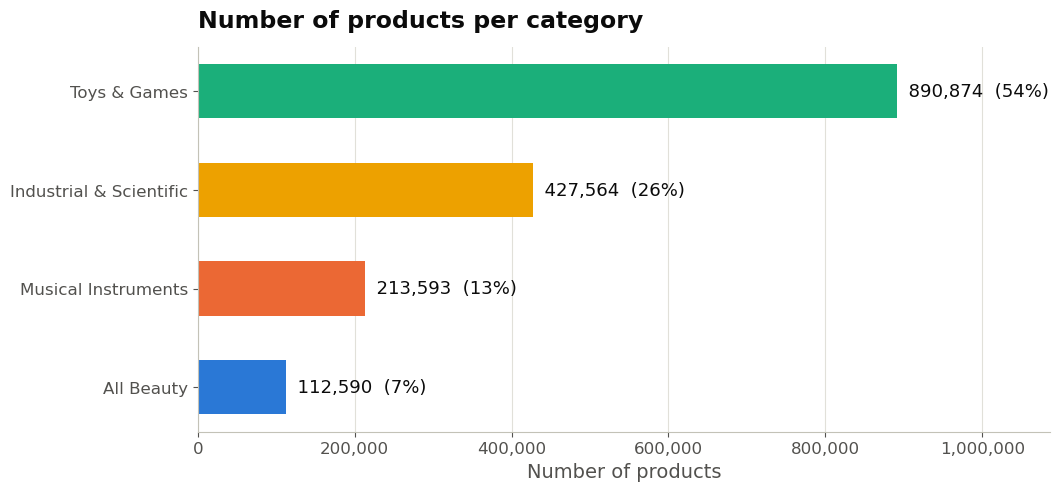

In [6]:
fig = viz.plot_category_counts(df)

**What it shows.** The categories are very different sizes. Toys & Games has 890,874 products (54% of the table) and All Beauty 112,590 (7%). Any statistic computed over all products together is therefore dominated by Toys & Games, which is why the other charts split by category.

## 4. Price vs average rating

Priced products only. About half of all products have no listed price:

In [7]:
(100 * df.groupby("category")["has_price"].mean()).round(1).rename("% of products with a price")

category
All_Beauty                   15.7
Industrial_and_Scientific    52.1
Musical_Instruments          39.7
Toys_and_Games               48.1
Name: % of products with a price, dtype: float64

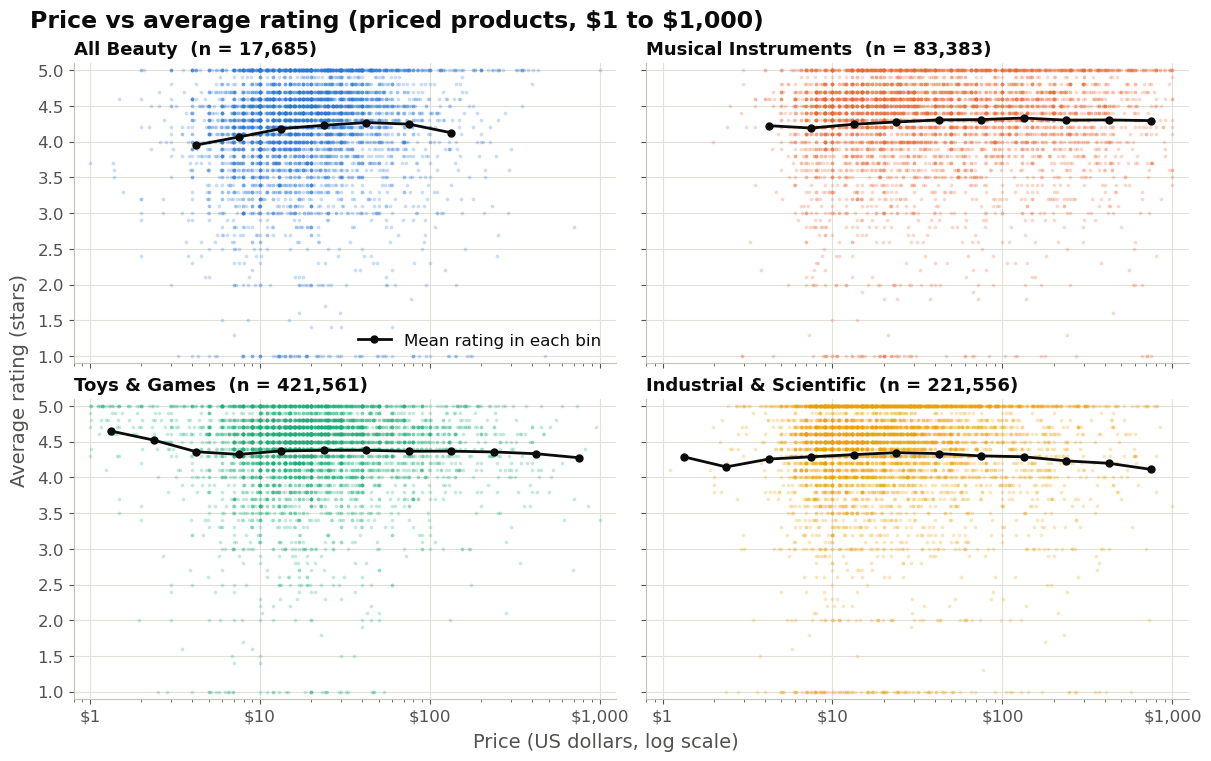

In [8]:
fig = viz.plot_price_vs_rating(df)

**What it shows.** Price has little relationship with rating. In Musical Instruments the trend line stays between about 4.2 and 4.3 stars from \$4 to \$750, and in Toys & Games and Industrial & Scientific it stays between about 4.1 and 4.4 from \$4 upward. The points form the same horizontal band at every price.

All Beauty is the exception: its mean rating rises from about 3.95 near \$4 to about 4.27 near \$40. Only 15.7% of Beauty products have a price, so this describes a small part of that category.

A trend-line point is drawn only where a price bin holds at least 200 products.

## 5. Number of ratings vs average rating

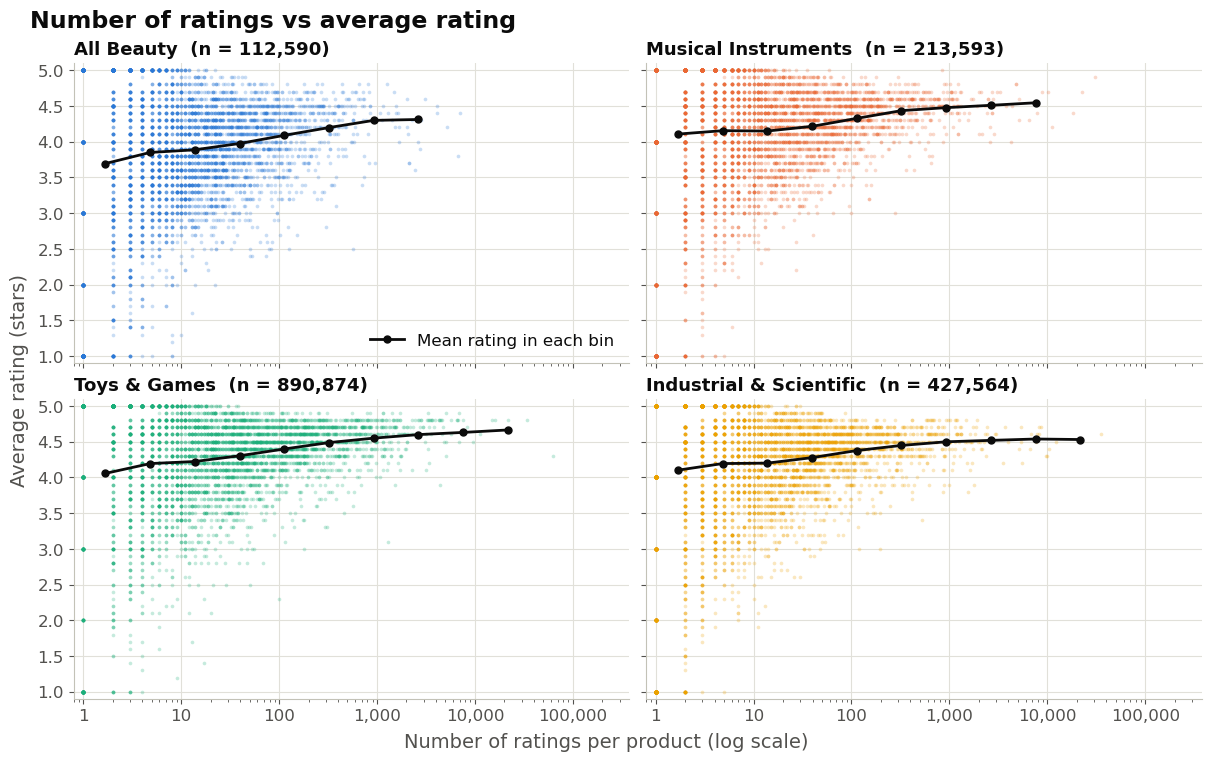

In [9]:
fig = viz.plot_review_volume_vs_rating(df)

**What it shows.** Two things. First, the points form a funnel: products with only a few ratings are spread across the whole 1 to 5 range, while heavily rated products cluster between about 4 and 5. An average of two or three ratings is noisy; an average of thousands is not.

Second, the trend line climbs in every category: products with more ratings have a higher mean rating.

## 6. Mean rating by review-volume band

The same relationship as chart 5, summarised with the bands Person 3 uses in `stats.review_volume_summary`. The table is shown first so every point on the chart can be checked.

In [10]:
from src import stats

volume_table = stats.review_volume_summary(df)
volume_table

category,All_Beauty,Industrial_and_Scientific,Musical_Instruments,Toys_and_Games,All
volume_band,,,,,
1-9,3.790,4.146,4.131,4.143,4.114
10-99,3.938,4.249,4.192,4.279,4.238
100-999,4.165,4.429,4.399,4.465,4.441
1k-9.9k,4.328,4.518,4.505,4.591,4.567
10k+,4.667,4.534,4.573,4.657,4.622


In [11]:
# Number of products behind each cell
volume_table.attrs["counts"]

category,All_Beauty,Industrial_and_Scientific,Musical_Instruments,Toys_and_Games
volume_band,,,,
1-9,56869,227691,110399,312025
10-99,46392,149761,77986,386369
100-999,8643,43857,22345,164429
1k-9.9k,656,5899,2741,27019
10k+,30,356,122,1032


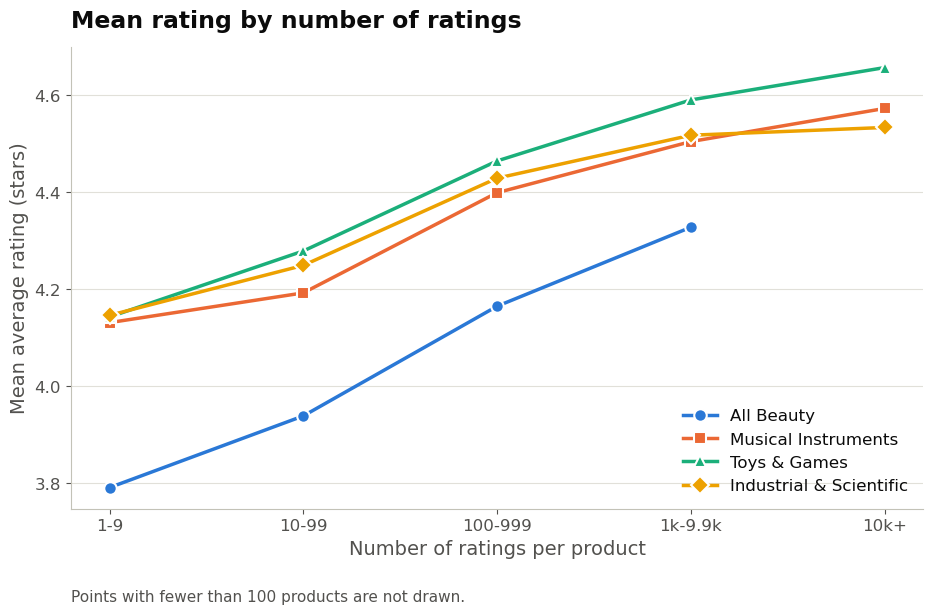

In [12]:
fig = viz.plot_rating_by_volume_band(df)

**What it shows.** Mean rating rises with the number of ratings in every category: over all products it goes from 4.114 for products with 1 to 9 ratings to 4.622 for products with 10,000 or more.

All Beauty sits below the other three in every band that is drawn. At 1,000 to 9,999 ratings it averages 4.328, against 4.505 to 4.591 for the others. That makes Beauty the first place to look for heavily reviewed products that still rate low.

The Beauty point for 10k+ is not drawn because only 30 products sit behind it (the chart requires at least 100).

## 7. Correlation heatmap

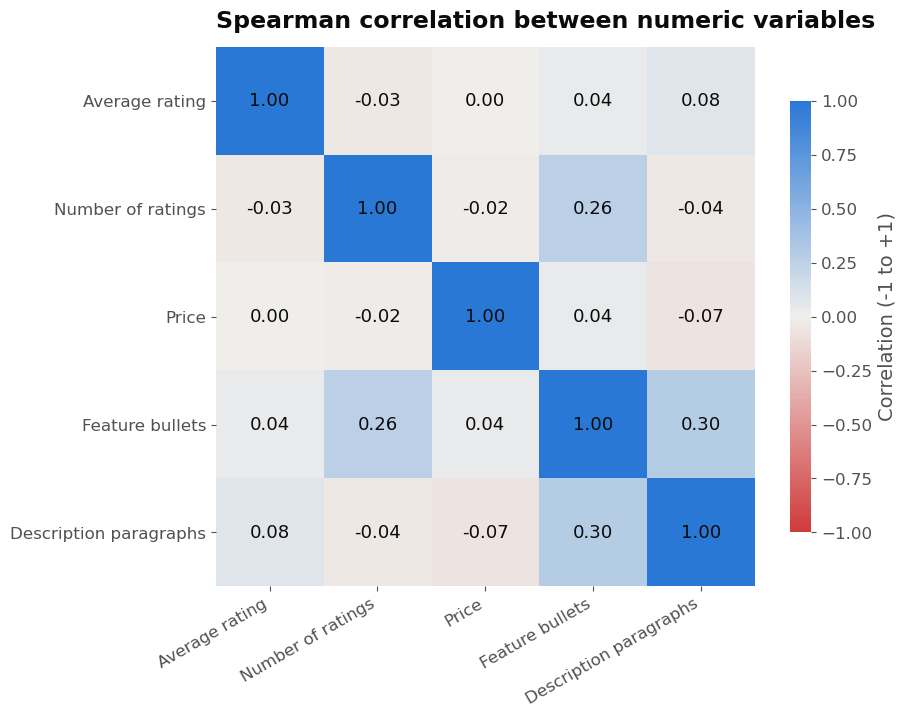

In [13]:
fig = viz.plot_correlation_heatmap(df)

**What it shows.** No numeric variable has a strong rank correlation with average rating: every value in the first row is between -0.03 and 0.08. Price is 0.00.

The strongest relationships are between listing details: feature bullets with description paragraphs (0.30) and feature bullets with number of ratings (0.26).

This does not contradict charts 5 and 6. Spearman gives one number for the whole relationship, and it is pulled toward zero by the many products with very few ratings that sit at exactly 5.0 (chart 1). The band chart shows the pattern that single number hides.

## Figures written

In [14]:
for path in sorted(viz.FIG_DIR.glob("*.png")):
    print(path.relative_to(viz.ROOT).as_posix(), f"{path.stat().st_size / 1024:,.0f} KB")

reports/figures/01_rating_distribution.png 59 KB
reports/figures/02_rating_by_category.png 58 KB
reports/figures/03_category_counts.png 58 KB
reports/figures/04_price_vs_rating.png 434 KB
reports/figures/05_review_volume_vs_rating.png 362 KB
reports/figures/06_rating_by_volume_band.png 110 KB
reports/figures/07_correlation_heatmap.png 124 KB


## Charts for the deck

The three that carry the story for Submission 1:

1. **Distribution of average rating** (chart 1): ratings are bunched at the top, so small gaps between groups matter.
2. **Average rating by category** (chart 2): All Beauty is the low-rated category.
3. **Mean rating by review-volume band** (chart 6): more-reviewed products rate higher, and Beauty stays lowest.

Associations only: none of these charts shows that price, category or review volume *causes* a rating.